In [1]:
import pandas as pd
import numpy as np

# 1. Cargar el dataset procesado
df_hmm = pd.read_csv('../data/processed/aves_procesado_markov.csv')
df_hmm['date'] = pd.to_datetime(df_hmm['date'])
df_hmm = df_hmm.sort_values(['trayectoria_id', 'date'])

# 2. Funciones para métricas físicas
def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi, dlambda = np.radians(lat2-lat1), np.radians(lon2-lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2 * r * np.arctan2(np.sqrt(a), np.sqrt(1-a))

def calculate_bearing(lat1, lon1, lat2, lon2):
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dlambda = np.radians(lon2-lon1)
    y = np.sin(dlambda) * np.cos(phi2)
    x = np.cos(phi1)*np.sin(phi2) - np.sin(phi1)*np.cos(phi2)*np.cos(dlambda)
    return (np.degrees(np.arctan2(y, x)) + 360) % 360

# 3. Calcular variables entre t y t+1
df_hmm['next_lat'] = df_hmm.groupby('trayectoria_id')['lat'].shift(-1)
df_hmm['next_lon'] = df_hmm.groupby('trayectoria_id')['lon'].shift(-1)

df_hmm['step_length'] = haversine_km(df_hmm['lat'], df_hmm['lon'], df_hmm['next_lat'], df_hmm['next_lon'])
df_hmm['bearing'] = calculate_bearing(df_hmm['lat'], df_hmm['lon'], df_hmm['next_lat'], df_hmm['next_lon'])

# 4. Calcular el cambio de ángulo (Turning Angle)
# Es la diferencia entre el rumbo actual y el anterior (crucial para detectar zigzag vs línea recta)
df_hmm['turning_angle'] = df_hmm.groupby('trayectoria_id')['bearing'].diff()
# Normalizar ángulos para que estén entre -pi y pi
df_hmm['turning_angle'] = np.arctan2(np.sin(np.radians(df_hmm['turning_angle'])), 
                                     np.cos(np.radians(df_hmm['turning_angle'])))

# Limpiamos NaNs producidos por los saltos entre trayectorias
df_hmm = df_hmm.dropna(subset=['step_length', 'turning_angle']).copy()

In [2]:
df_hmm.head()

,animal_id,date,hora,lon,lat,veg_low,veg_high,trayectoria_id,next_lat,next_lon,step_length,bearing,turning_angle
310,91732A,2010-04-19,14,32.50833,29.85733,0.011392,0.000634,91732A_Seg10,29.93017,32.46767,8.998029,334.185906,-0.234703
311,91732A,2010-04-20,14,32.46767,29.93017,0.013096,0.000745,91732A_Seg10,29.80717,32.49333,13.898980,169.739306,-2.870135
312,91732A,2010-04-21,14,32.49333,29.80717,0.011206,0.000614,91732A_Seg10,29.92867,32.47817,13.589038,353.828355,-3.070225
313,91732A,2010-04-22,14,32.47817,29.92867,0.012829,0.000729,91732A_Seg10,29.80250,32.46033,14.134539,186.995070,-2.911790
314,91732A,2010-04-23,14,32.46033,29.80250,0.011860,0.000651,91732A_Seg10,30.02050,32.48600,24.366432,5.821447,3.121109


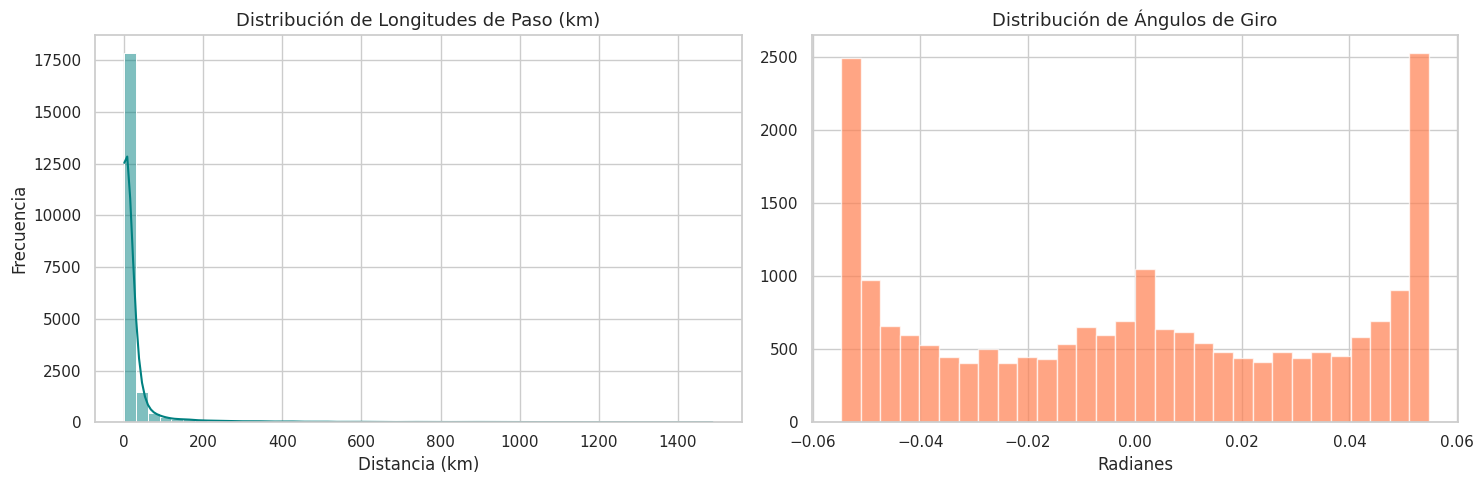

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

# 1. Histograma de Distancias (Step Length)
plt.subplot(1, 2, 1)
sns.histplot(df_hmm['step_length'], bins=50, kde=True, color='teal')
plt.title('Distribución de Longitudes de Paso (km)', fontsize=13)
plt.xlabel('Distancia (km)')
plt.ylabel('Frecuencia')

# 2. Gráfico Polar para los Ángulos de Giro (Turning Angle)
# Esto nos dice si el ave prefiere ir recto o girar
plt.subplot(1, 2, 2)
# Convertimos a radianes para el gráfico polar
angles_rad = np.radians(df_hmm['turning_angle'].dropna())
plt.hist(angles_rad, bins=30, color='coral', alpha=0.7)
plt.title('Distribución de Ángulos de Giro', fontsize=13)
plt.xlabel('Radianes')

plt.tight_layout()
plt.show()

In [4]:
from hmmlearn import hmm
import numpy as np

# 1. Seleccionamos las 4 variables predictoras
variables_hmm = ['step_length', 'turning_angle', 'veg_low', 'veg_high']

# 2. Limpieza final: eliminamos cualquier fila con NaN en estas columnas
df_hmm_ready = df_hmm.dropna(subset=variables_hmm).copy()

# 3. Preparar la matriz de datos X
X = df_hmm_ready[variables_hmm].values

# 4. Configurar el HMM para 2 estados (Reposo vs. Movimiento)
# Usamos 'diag' para que el modelo estime una varianza independiente para cada variable
model = hmm.GaussianHMM(
    n_components=2, 
    covariance_type="diag", 
    n_iter=2000, 
    random_state=42
)

# 5. Entrenar el modelo
model.fit(X)

# 6. Predecir y guardar el estado en el DataFrame
df_hmm_ready['estado_hmm'] = model.predict(X)

print("¡HMM entrenado con éxito incluyendo cobertura vegetal!")
print(df_hmm_ready['estado_hmm'].value_counts())

¡HMM entrenado con éxito incluyendo cobertura vegetal!
estado_hmm
1    16463
0     4618
Name: count, dtype: int64


In [5]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. Definir la resolución y mínimos (asegúrate de que estos valores coincidan con tu análisis previo)
res = 0.5
lon_min = df_hmm_ready['lon'].min()
lat_min = df_hmm_ready['lat'].min()

# 2. Crear las celdas en el dataframe actual
df_hmm_ready['grid_x'] = ((df_hmm_ready['lon'] - lon_min) / res).astype(int)
df_hmm_ready['grid_y'] = ((df_hmm_ready['lat'] - lat_min) / res).astype(int)
df_hmm_ready['cell_id'] = df_hmm_ready['grid_x'].astype(str) + "_" + df_hmm_ready['grid_y'].astype(str)

# 3. Ordenar por animal y tiempo
df_hmm_ready = df_hmm_ready.sort_values(['animal_id', 'date'])

# 4. Crear el target_cell (¡Ahora sí encontrará 'cell_id'!)
df_hmm_ready['target_cell'] = df_hmm_ready.groupby('animal_id')['cell_id'].shift(-1)

# 5. Limpieza de NaNs generados por el shift
df_hmm_ready = df_hmm_ready.dropna(subset=['target_cell'])

# 6. OPCIONAL: Convertir a numérico para que los modelos de ML no den problemas
le = LabelEncoder()
df_hmm_ready['target_num'] = le.fit_transform(df_hmm_ready['target_cell'])

print("Variable objetivo creada con éxito.")
print(f"Celdas únicas a predecir: {df_hmm_ready['target_num'].nunique()}")

Variable objetivo creada con éxito.
Celdas únicas a predecir: 1176


In [7]:
df_hmm_ready.head()

,animal_id,date,hora,lon,lat,veg_low,veg_high,trayectoria_id,next_lat,next_lon,step_length,bearing,turning_angle,estado_hmm,grid_x,grid_y,cell_id,target_cell,target_num,mes_num
1,91732A,2009-06-03,14,24.58617,61.24783,0.039229,0.960771,91732A_Seg3,61.24783,24.58583,0.018186,270.000149,-2.544344,1,33,127,33_127,33_127,283,6
2,91732A,2009-06-04,14,24.58583,61.24783,0.039279,0.960721,91732A_Seg3,61.23467,24.51350,4.136986,249.316831,-0.360992,1,33,127,33_127,33_127,283,6
3,91732A,2009-06-05,14,24.51350,61.23467,0.051076,0.948924,91732A_Seg3,61.24717,24.53950,1.966400,45.009957,2.717358,1,33,127,33_127,33_127,283,6
6,91732A,2009-06-13,14,24.59967,61.24567,0.037372,0.962628,91732A_Seg6,61.10667,24.55533,15.637810,188.762568,1.446032,1,33,127,33_127,33_127,283,6
7,91732A,2009-06-14,14,24.55533,61.10667,0.054248,0.945752,91732A_Seg6,61.24817,24.58700,15.825411,6.144607,3.095901,1,33,127,33_127,33_127,283,6


In [8]:
df_hmm_ready.columns

Index(['animal_id', 'date', 'hora', 'lon', 'lat', 'veg_low', 'veg_high',
       'trayectoria_id', 'next_lat', 'next_lon', 'step_length', 'bearing',
       'turning_angle', 'estado_hmm', 'grid_x', 'grid_y', 'cell_id',
       'target_cell', 'target_num', 'mes_num'],
      dtype='str')

In [9]:
df_hmm_ready.to_csv('../data/processed/hmm.csv', index=False)

In [10]:
df_hmm_ready.head()

,animal_id,date,hora,lon,lat,veg_low,veg_high,trayectoria_id,next_lat,next_lon,step_length,bearing,turning_angle,estado_hmm,grid_x,grid_y,cell_id,target_cell,target_num,mes_num
1,91732A,2009-06-03,14,24.58617,61.24783,0.039229,0.960771,91732A_Seg3,61.24783,24.58583,0.018186,270.000149,-2.544344,1,33,127,33_127,33_127,283,6
2,91732A,2009-06-04,14,24.58583,61.24783,0.039279,0.960721,91732A_Seg3,61.23467,24.51350,4.136986,249.316831,-0.360992,1,33,127,33_127,33_127,283,6
3,91732A,2009-06-05,14,24.51350,61.23467,0.051076,0.948924,91732A_Seg3,61.24717,24.53950,1.966400,45.009957,2.717358,1,33,127,33_127,33_127,283,6
6,91732A,2009-06-13,14,24.59967,61.24567,0.037372,0.962628,91732A_Seg6,61.10667,24.55533,15.637810,188.762568,1.446032,1,33,127,33_127,33_127,283,6
7,91732A,2009-06-14,14,24.55533,61.10667,0.054248,0.945752,91732A_Seg6,61.24817,24.58700,15.825411,6.144607,3.095901,1,33,127,33_127,33_127,283,6


In [11]:
df_hmm_ready.columns

Index(['animal_id', 'date', 'hora', 'lon', 'lat', 'veg_low', 'veg_high',
       'trayectoria_id', 'next_lat', 'next_lon', 'step_length', 'bearing',
       'turning_angle', 'estado_hmm', 'grid_x', 'grid_y', 'cell_id',
       'target_cell', 'target_num', 'mes_num'],
      dtype='str')

In [12]:
# Mostrar las medias de cada estado para las 4 variables
means_df = pd.DataFrame(
    model.means_, 
    columns=variables_hmm, 
    index=['Estado 0', 'Estado 1']
)

print("\n--- Perfil de los Estados Ocultos ---")
print(means_df)


--- Perfil de los Estados Ocultos ---
          step_length  turning_angle   veg_low  veg_high
Estado 0   119.867653       0.029937  0.155081  0.333543
Estado 1     3.897056      -0.011611  0.223815  0.334019


In [13]:
import numpy as np

# Extraer las varianzas
covs = np.array(model.covars_)

print("--- VARIANZAS POR ESTADO ---")
print(f"Variables: {variables_hmm}")
print(f"Estado 0 (Migración): {covs[0]}")
print(f"Estado 1 (Reposo):    {covs[1]}")

--- VARIANZAS POR ESTADO ---
Variables: ['step_length', 'turning_angle', 'veg_low', 'veg_high']
Estado 0 (Migración): [[4.10118169e+04 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 3.68501758e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 4.97484431e-02 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 1.42995998e-01]]
Estado 1 (Reposo):    [[25.61129745  0.          0.          0.        ]
 [ 0.          4.87026627  0.          0.        ]
 [ 0.          0.          0.06233188  0.        ]
 [ 0.          0.          0.          0.12646744]]


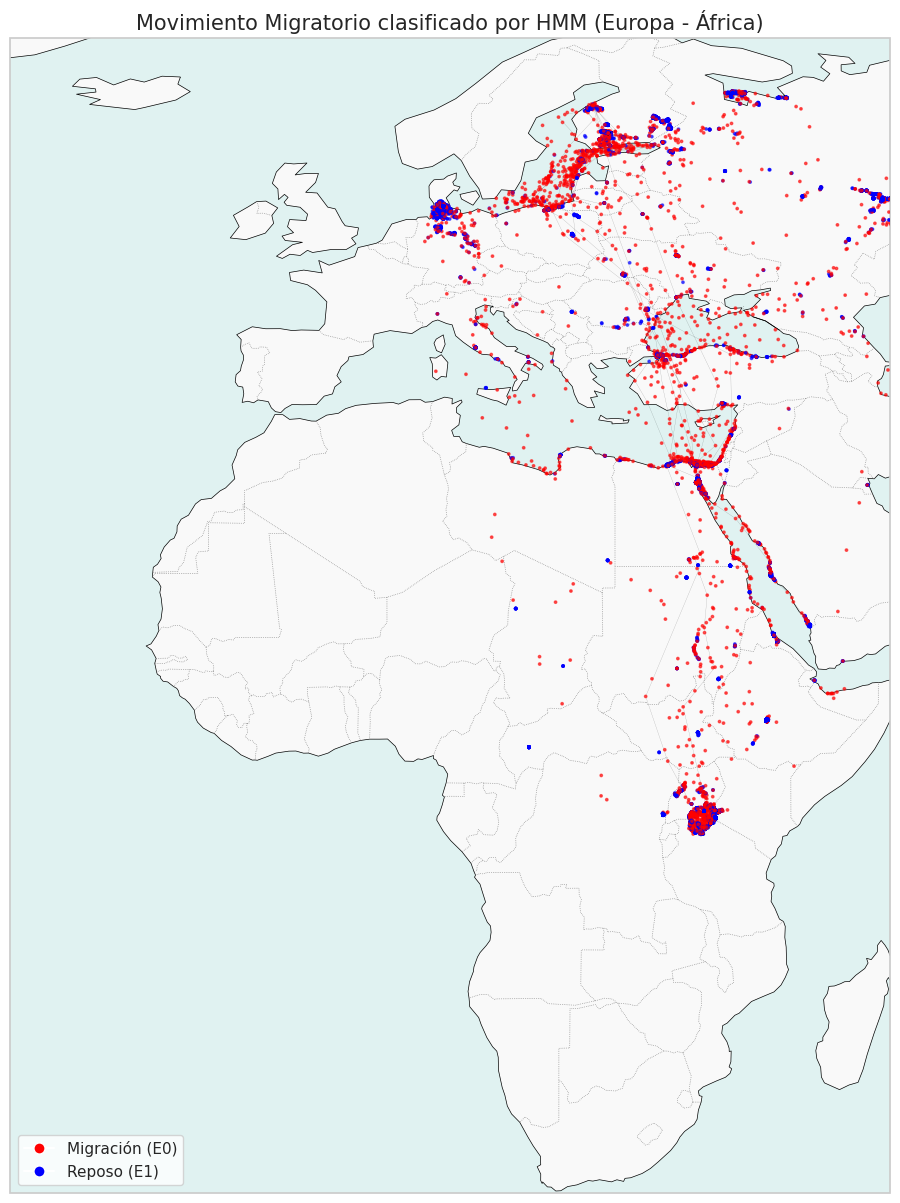

In [14]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D

# 1. Configuración de la figura
fig = plt.figure(figsize=(12, 15))
ax = plt.axes(projection=ccrs.PlateCarree()) # Cambiamos a PlateCarree para facilitar límites globales

# 2. Capas geográficas detalladas
ax.add_feature(cfeature.LAND, facecolor='#f9f9f9')
ax.add_feature(cfeature.OCEAN, facecolor='#e0f2f1')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5, edgecolor='gray')

# 3. Dibujar los puntos del HMM
# Mapeo: 0 -> Rojo (Migración), 1 -> Azul (Reposo)
colors = {0: 'red', 1: 'blue'}
ax.scatter(df_hmm_ready['lon'], df_hmm_ready['lat'], 
           c=df_hmm_ready['estado_hmm'].map(colors),
           s=3, alpha=0.6, transform=ccrs.PlateCarree(), zorder=3)

# 4. LÍMITES PARA VER EUROPA Y ÁFRICA COMPLETAS
# [Oeste, Este, Sur, Norte]
ax.set_extent([-30, 50, -35, 70], crs=ccrs.PlateCarree())

# 5. Dibujar algunas trayectorias para ver continuidad
for tray_id in df_hmm_ready['trayectoria_id'].unique()[:50]:
    subset = df_hmm_ready[df_hmm_ready['trayectoria_id'] == tray_id]
    ax.plot(subset['lon'], subset['lat'], color='black', linewidth=0.2, 
            alpha=0.3, transform=ccrs.PlateCarree(), zorder=2)

# 6. Leyenda y Título
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Migración (E0)',
                          markerfacecolor='red', markersize=8),
                   Line2D([0], [0], marker='o', color='w', label='Reposo (E1)',
                          markerfacecolor='blue', markersize=8)]
ax.legend(handles=legend_elements, loc='lower left')

plt.title('Movimiento Migratorio clasificado por HMM (Europa - África)', fontsize=15)
plt.show()

In [15]:
print(df_hmm_ready.columns.tolist())

['animal_id', 'date', 'hora', 'lon', 'lat', 'veg_low', 'veg_high', 'trayectoria_id', 'next_lat', 'next_lon', 'step_length', 'bearing', 'turning_angle', 'estado_hmm', 'grid_x', 'grid_y', 'cell_id', 'target_cell', 'target_num', 'mes_num']


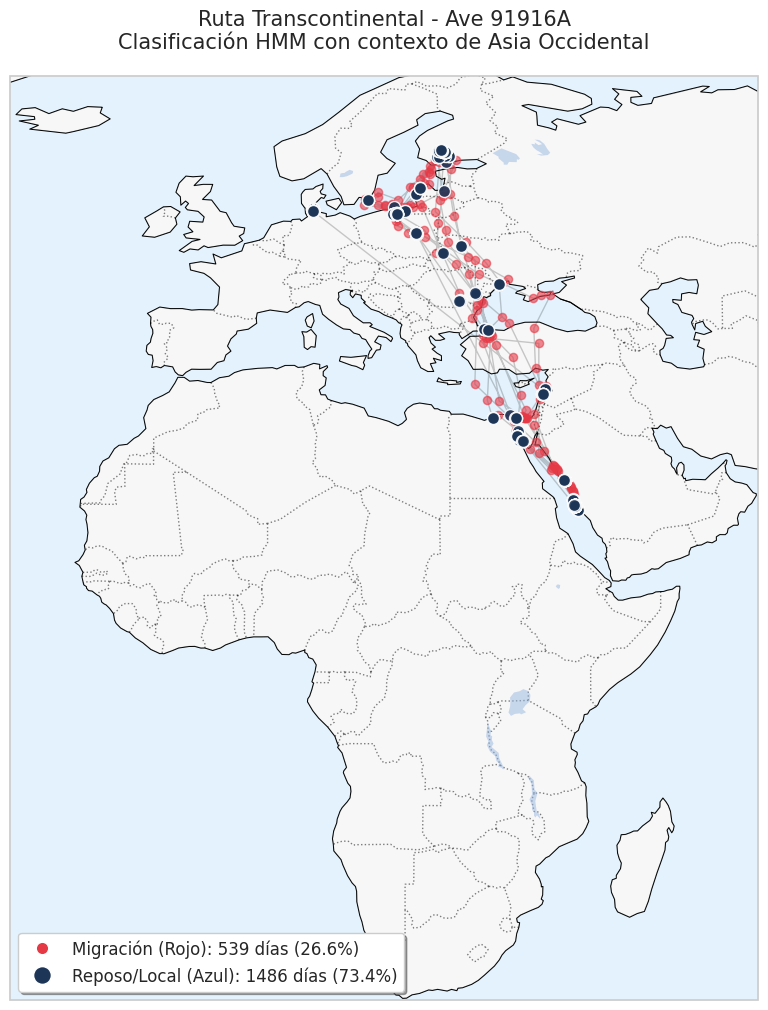

In [16]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D

# 1. Configuración del ID
id_ave = '91916A'
col_id = 'animal_id' 

# 2. Filtrar y asegurar orden cronológico
df_ave = df_hmm_ready[df_hmm_ready[col_id] == id_ave].sort_values('date')

# Separar estados para capas de dibujo
df_rep = df_ave[df_ave['estado_hmm'] == 1] # Reposo
df_mig = df_ave[df_ave['estado_hmm'] == 0] # Migración

# 3. Estadísticas
n_mig = len(df_mig)
n_rep = len(df_rep)
total = len(df_ave)
pct_mig = (n_mig / total) * 100 if total > 0 else 0

# 4. Crear el mapa
fig = plt.figure(figsize=(15, 12)) 
ax = plt.axes(projection=ccrs.PlateCarree())

# Capas base detalladas
ax.add_feature(cfeature.LAND, facecolor='#f7f7f7', edgecolor='#b0b0b0', zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor='#e3f2fd', zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7, zorder=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5, zorder=1)
ax.add_feature(cfeature.LAKES, alpha=0.5, zorder=1) # Añadimos lagos para más detalle en África/Asia

# Trayectoria (línea de fondo)
ax.plot(df_ave['lon'], df_ave['lat'], color='black', lw=1.0, alpha=0.2, 
        transform=ccrs.PlateCarree(), zorder=2)

# Capa de Migración (Rojo)
ax.scatter(df_mig['lon'], df_mig['lat'], 
           color='#e63946', s=35, alpha=0.6,
           transform=ccrs.PlateCarree(), zorder=3)

# Capa de Reposo (Azul) - MÁXIMA VISIBILIDAD
ax.scatter(df_rep['lon'], df_rep['lat'], 
           color='#1d3557', s=75, # Más grandes
           edgecolors='white', linewidth=1.0, # Borde blanco marcado
           alpha=0.9, 
           transform=ccrs.PlateCarree(), zorder=4)

# 5. EXTENSIÓN PARA EUROPA, ÁFRICA Y ASIA OCCIDENTAL
# [Oeste: -25, Este: 60 (Cubre Arabia y parte de Asia), Sur: -35, Norte: 70]
ax.set_extent([-25, 60, -35, 70], crs=ccrs.PlateCarree())

# 6. Leyenda y Título
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=f'Migración (Rojo): {n_mig} días ({pct_mig:.1f}%)',
           markerfacecolor='#e63946', markersize=9),
    Line2D([0], [0], marker='o', color='w', label=f'Reposo/Local (Azul): {n_rep} días ({100-pct_mig:.1f}%)',
           markerfacecolor='#1d3557', markersize=13, markeredgecolor='white', markeredgewidth=1.2)
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=12, frameon=True, shadow=True)

plt.title(f"Ruta Transcontinental - Ave {id_ave}\nClasificación HMM con contexto de Asia Occidental", fontsize=15, pad=20)

plt.show()

In [17]:
# 1. Amplía el extent para ver África (Latitud hasta 10 o 20)
ax.set_extent([-25, 20, 10, 65], crs=ccrs.PlateCarree()) 

# 2. Dibuja las líneas de trayectoria (opcional pero recomendado)
# Esto ayudará a ver si los puntos rojos realmente forman una ruta
for tray_id in df_hmm_ready['trayectoria_id'].unique()[:20]: # Dibujamos solo 20 para no saturar
    subset = df_hmm_ready[df_hmm_ready['trayectoria_id'] == tray_id]
    ax.plot(subset['lon'], subset['lat'], color='black', linewidth=0.3, 
            alpha=0.3, transform=ccrs.PlateCarree())

# 3. Aumenta un poco el tamaño de los puntos rojos para que resalten
# ya que son menos que los azules